# Sensitivity Analysis

In [22]:
import os, sqlite3
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

os.makedirs('./overleaf', exist_ok=True)

# ── Font size — edit only this one value ─────────────────────────────────────
FS = 16
# ─────────────────────────────────────────────────────────────────────────────
FS_AXIS_LABEL  = FS
FS_PANEL_LABEL = FS + 1
FS_LEGEND      = FS - 0.5
FS_BASE        = FS

# ── Bottom padding for each saved plot (fraction of figure height, 0.0–0.5) ──
# 0.15 = small pad  |  0.20 = default  |  0.30 = generous
BOTTOM_PAD = 0.20

RESULT_DB = './results/result.db'

ENC_ORDER  = ['only_structured', 'label', 'count', 'tfidf', 'clinicalbert', 'sentencebert']
ENC_LABELS = {'only_structured': 'Struct. only', 'label': 'Label', 'count': 'Count', 'tfidf': 'TF–IDF', 'clinicalbert': 'ClinicalBERT', 'sentencebert': 'Sentence-BERT'}
# Okabe-Ito palette — designed for maximum perceptual discrepancy
# across all forms of color vision deficiency (Nature/Science standard)
COLORS     = {'only_structured': '#555555', 'label': '#D55E00', 'count': '#E69F00', 'tfidf': '#CC79A7', 'clinicalbert': '#0072B2', 'sentencebert': '#009E73'}
MARKERS    = {'only_structured': 's', 'label': 'o', 'count': '^', 'tfidf': 'D', 'clinicalbert': 'v', 'sentencebert': '*'}

METRIC_CFG = [
    ('mae',           'MAE (min)',  False, 'sensitivity_mae.pdf'),
    ('smape',         'SMAPE (%)',  False, 'sensitivity_smape.pdf'),
    ('r2',            '$R^2$',      True,  'sensitivity_r2.pdf'),
    ('train_time_s',  'Train time (s)', False, 'sensitivity_traintime.pdf'),
]

with sqlite3.connect(RESULT_DB) as conn:
    df = __import__('pandas').read_sql("SELECT encoding, n_features, fold, mae, smape, r2, train_time_s FROM metrics", conn)

struct_means = df[df['encoding'] == 'only_structured'].groupby('fold')[['mae','smape','r2','train_time_s']].mean()
n_vals = sorted([n for n in df['n_features'].unique() if n > 0])

plt.rcParams.update({
    'font.family':      'serif',
    'font.size':        FS_BASE,
    'axes.linewidth':   1.0,
    'axes.edgecolor':   '#222222',
    'xtick.direction':  'out',
    'ytick.direction':  'out',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'figure.dpi':       150,
})

def make_panel(metric, ylabel, higher_better):
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.set_facecolor('white')
    ax.grid(axis='y', color='#dddddd', linewidth=0.7, linestyle=':', zorder=0)
    ax.grid(axis='x', color='#eeeeee', linewidth=0.5, linestyle=':', zorder=0)
    for enc in ENC_ORDER:
        c = COLORS[enc]; m = MARKERS[enc]
        if enc == 'only_structured':
            mu = struct_means[metric].mean()
            ax.axhline(mu, color=c, linestyle=(0, (6, 3)), linewidth=1.6, zorder=3, alpha=0.85)
            continue
        sub = df[(df['encoding'] == enc) & (df['n_features'].isin(n_vals))]
        grp = sub.groupby('n_features')[metric].mean().reindex(n_vals)
        ms = 10 if m == '*' else 7
        # shadow pass — slightly offset, transparent
        ax.plot(n_vals, grp, marker=m, color='black', linewidth=0, markersize=ms + 3, alpha=0.08, zorder=3)
        ax.plot(n_vals, grp, marker=m, color=c, linewidth=2.2, markersize=ms, markeredgecolor='white', markeredgewidth=1.2, zorder=5, alpha=0.92)
    ax.set_xlabel('Text features per field ($n$)', fontsize=FS_AXIS_LABEL)
    ax.set_ylabel(ylabel, fontsize=FS_AXIS_LABEL)
    ax.set_xticks(n_vals)
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.tick_params(labelsize=FS_BASE)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    fig.subplots_adjust(bottom=BOTTOM_PAD)
    return fig

# ── Save each metric panel as its own PDF ────────────────────────────────────
for metric, ylabel, higher_better, fname in METRIC_CFG:
    fig = make_panel(metric, ylabel, higher_better)
    out = os.path.join('./overleaf', fname)
    fig.savefig(out, dpi=300)
    plt.close(fig)
    print(f'Saved → {out}')

# ── Save legend as its own PDF ───────────────────────────────────────────────
legend_handles = [
    Line2D([0], [0], color=COLORS[enc], marker=MARKERS[enc], linewidth=2.0,
           markersize=8 if MARKERS[enc] == '*' else 6,
           markeredgecolor='white', markeredgewidth=0.8,
           linestyle=(0, (5, 3)) if enc == 'only_structured' else '-',
           label=ENC_LABELS[enc])
    for enc in ENC_ORDER
]
# ── Print average values for all metrics, encodings, and n values ────────────
METRIC_PRINT = [('mae', 'MAE (min)'), ('smape', 'SMAPE (%)'), ('r2', 'R²'), ('train_time_s', 'Train Time (s)')]
SEP = '─' * 72

LOG_PATH = './overleaf/sensitivity_values.log'

def _build_log():
    lines = []
    lines.append(f'{"═"*72}')
    lines.append(f'  SENSITIVITY ANALYSIS — AVERAGE VALUES ACROSS FOLDS')
    lines.append(f'{"═"*72}')
    for metric, metric_label in METRIC_PRINT:
        lines.append(f'\n{SEP}')
        lines.append(f'  Metric: {metric_label}')
        lines.append(SEP)
        mu_struct = struct_means[metric].mean()
        header = f'  {"Encoding":<20}  {"n=struct":>10}' + ''.join(f'  {"n="+str(n):>10}' for n in n_vals)
        lines.append(header)
        lines.append(f'  {"-"*20}  ' + '  '.join(['-'*10] * (1 + len(n_vals))))
        for enc in ENC_ORDER:
            row_str = f'  {ENC_LABELS[enc]:<20}  '
            if enc == 'only_structured':
                row_str += f'{mu_struct:>10.4f}' + ''.join(f'  {"(baseline)":>10}' for _ in n_vals)
            else:
                row_str += f'  {"—":>9}'
                sub = df[(df['encoding'] == enc) & (df['n_features'].isin(n_vals))]
                grp = sub.groupby('n_features')[metric].mean().reindex(n_vals)
                row_str += ''.join(f'  {grp.loc[n]:>10.4f}' for n in n_vals)
            lines.append(row_str)
    lines.append(f'\n{"═"*72}')
    return '\n'.join(lines)

log_text = _build_log()
print(log_text)
with open(LOG_PATH, 'w', encoding='utf-8') as f:
    f.write(log_text + '\n')
print(f'Saved → {LOG_PATH}')

fig_leg, ax_leg = plt.subplots(figsize=(8, 0.5))
ax_leg.axis('off')
ax_leg.legend(handles=legend_handles, loc='center', ncol=len(ENC_ORDER), fontsize=FS_LEGEND, frameon=True, framealpha=0.95, edgecolor='#cccccc')
out_leg = './overleaf/sensitivity_legend.pdf'
fig_leg.savefig(out_leg, bbox_inches='tight', dpi=300)
plt.close(fig_leg)
print(f'Saved → {out_leg}')

Saved → ./overleaf\sensitivity_mae.pdf
Saved → ./overleaf\sensitivity_smape.pdf
Saved → ./overleaf\sensitivity_r2.pdf
Saved → ./overleaf\sensitivity_traintime.pdf
════════════════════════════════════════════════════════════════════════
  SENSITIVITY ANALYSIS — AVERAGE VALUES ACROSS FOLDS
════════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────────────────
  Metric: MAE (min)
────────────────────────────────────────────────────────────────────────
  Encoding                n=struct        n=10        n=50       n=100       n=200
  --------------------  ----------  ----------  ----------  ----------  ----------
  Struct. only             41.0823  (baseline)  (baseline)  (baseline)  (baseline)
  Label                           —     40.5852     38.0900     37.0879     34.8199
  Count                           —     40.4438     37.4426     36.1627     34.2850
  TF–IDF                          —     40.4544     37

In [23]:
import sqlite3
import numpy as np
import pandas as pd
import os

RESULT_DB_TEMPORAL = './results_temporal/result.db'
LOG_OUT = './Overleaf/temporal_cv_results.log'

os.makedirs(os.path.dirname(LOG_OUT), exist_ok=True)

ENCODE_LABELS = {
    'only_structured': 'Structured only',
    'label':           'Label',
    'count':           'Count',
    'tfidf':           'TF-IDF',
    'clinicalbert':    'ClinicalBERT',
    'sentencebert':    'Sentence-BERT',
}
ENCODE_ORDER = list(ENCODE_LABELS.keys())
MODEL_ORDER  = ['linear', 'ridge', 'lasso', 'randomforest', 'xgboost', 'mlp']

with sqlite3.connect(RESULT_DB_TEMPORAL) as conn:
    df = pd.read_sql("SELECT * FROM metrics", conn)

lines = []
def log(s=''):
    lines.append(s)
    print(s)

def sep(title='', char='=', width=100):
    if title:
        log(char * width)
        log(f'  {title}')
        log(char * width)
    else:
        log(char * width)

sep('TEMPORAL CV — RESULTS SUMMARY')
log(f'  CV strategy  : Expanding-window TimeSeriesSplit  (k=5)')
log(f'  Primary n    : 100 features per text field')
log(f'  Models       : {MODEL_ORDER}')
log(f'  Encodings    : {ENCODE_ORDER}')
log()

# ── Per-fold breakdown ────────────────────────────────────────────────────────
sep('PER-FOLD RESULTS  (n=100, all models)', char='-')
sub = df[(df['n_features'] == 100) | (df['n_features'] == 0)].copy()
sub['enc_ord'] = sub['encoding'].map({e: i for i, e in enumerate(ENCODE_ORDER)})
sub['mdl_ord'] = sub['model'].map({m: i for i, m in enumerate(MODEL_ORDER)})
sub = sub.sort_values(['mdl_ord', 'enc_ord', 'fold'])

log(f"  {'Model':<14} {'Encoding':<20} {'Fold':>5}  {'MAE':>8} {'SMAPE':>8} {'R²':>8} {'RMSE':>8}")
log(f"  {'-'*78}")
for _, row in sub.iterrows():
    enc = ENCODE_LABELS.get(row['encoding'], row['encoding'])
    log(f"  {row['model']:<14} {enc:<20} {int(row['fold']):>5}  {row['mae']:>8.3f} {row['smape']:>8.3f} {row['r2']:>8.4f} {row['rmse']:>8.3f}")

# ── Aggregated across folds: per model × encoding ────────────────────────────
sep('AGGREGATED  (mean ± std across 5 temporal folds)  —  per model × encoding', char='-')
agg = (
    sub.groupby(['model', 'encoding'])[['mae', 'smape', 'r2', 'rmse']]
    .agg(['mean', 'std'])
    .round(3)
)
agg.columns = ['_'.join(c) for c in agg.columns]
agg = agg.reset_index()
agg['enc_ord'] = agg['encoding'].map({e: i for i, e in enumerate(ENCODE_ORDER)})
agg['mdl_ord'] = agg['model'].map({m: i for i, m in enumerate(MODEL_ORDER)})
agg = agg.sort_values(['mdl_ord', 'enc_ord']).drop(columns=['enc_ord', 'mdl_ord'])

log(f"  {'Model':<14} {'Encoding':<20} {'MAE mean':>10} {'±':>5} {'SMAPE mean':>11} {'±':>5} {'R² mean':>9} {'±':>7} {'RMSE mean':>10} {'±':>5}")
log(f"  {'-'*104}")
for _, row in agg.iterrows():
    enc = ENCODE_LABELS.get(row['encoding'], row['encoding'])
    log(f"  {row['model']:<14} {enc:<20} {row['mae_mean']:>10.3f} {row['mae_std']:>5.3f} {row['smape_mean']:>11.3f} {row['smape_std']:>5.3f} {row['r2_mean']:>9.4f} {row['r2_std']:>7.4f} {row['rmse_mean']:>10.3f} {row['rmse_std']:>5.3f}")

# ── Aggregated across folds AND models: one row per encoding ──────────────────
sep('AGGREGATED  (mean ± std across 5 folds × 6 models)  —  per encoding only', char='-')
agg2 = (
    sub.groupby('encoding')[['mae', 'smape', 'r2', 'rmse']]
    .agg(['mean', 'std'])
    .round(3)
)
agg2.columns = ['_'.join(c) for c in agg2.columns]
agg2 = agg2.reset_index()
agg2['enc_ord'] = agg2['encoding'].map({e: i for i, e in enumerate(ENCODE_ORDER)})
agg2 = agg2.sort_values('enc_ord').drop(columns='enc_ord')

log(f"  {'Encoding':<20} {'MAE mean':>10} {'±':>5} {'SMAPE mean':>11} {'±':>5} {'R² mean':>9} {'±':>7} {'RMSE mean':>10} {'±':>5}")
log(f"  {'-'*85}")
for _, row in agg2.iterrows():
    enc = ENCODE_LABELS.get(row['encoding'], row['encoding'])
    log(f"  {enc:<20} {row['mae_mean']:>10.3f} {row['mae_std']:>5.3f} {row['smape_mean']:>11.3f} {row['smape_std']:>5.3f} {row['r2_mean']:>9.4f} {row['r2_std']:>7.4f} {row['rmse_mean']:>10.3f} {row['rmse_std']:>5.3f}")

# ── Best configuration ────────────────────────────────────────────────────────
sep('BEST CONFIGURATION PER METRIC  (n=100)', char='-')
for metric, direction in [('mae_mean', 'min'), ('smape_mean', 'min'), ('r2_mean', 'max'), ('rmse_mean', 'min')]:
    idx  = agg[metric].idxmin() if direction == 'min' else agg[metric].idxmax()
    best = agg.loc[idx]
    enc  = ENCODE_LABELS.get(best['encoding'], best['encoding'])
    log(f"  Best {metric:<14}: model={best['model']:<14} encoding={enc:<20} value={best[metric]:.4f}")

sep()
log(f'  Log saved → {LOG_OUT}')

with open(LOG_OUT, 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))

print(f'\n✅ Done.')

  TEMPORAL CV — RESULTS SUMMARY
  CV strategy  : Expanding-window TimeSeriesSplit  (k=5)
  Primary n    : 100 features per text field
  Models       : ['linear', 'ridge', 'lasso', 'randomforest', 'xgboost', 'mlp']
  Encodings    : ['only_structured', 'label', 'count', 'tfidf', 'clinicalbert', 'sentencebert']

----------------------------------------------------------------------------------------------------
  PER-FOLD RESULTS  (n=100, all models)
----------------------------------------------------------------------------------------------------
  Model          Encoding              Fold       MAE    SMAPE       R²     RMSE
  ------------------------------------------------------------------------------
  linear         Structured only          0    47.056   42.476   0.6645   65.850
  linear         Structured only          1    46.547   45.509   0.6617   64.666
  linear         Structured only          2    46.721   47.174   0.6439   63.144
  linear         Structured only          

In [35]:
# =============================================================================
# generate_main_results_table.py
#
# Generates a single LaTeX table matching the style of tab:results_std,
# filtered to n=100 text features only, with all six metrics including MAPE.
# Grouped by encoding (italic headers), rows are models.
#
# Output saved to ./overleaf/main_results_table.log
#
# Usage:
#   python generate_main_results_table.py
#
# Requires: result.db populated by Stage 04 of pipeline.py.
# =============================================================================

import os
import sqlite3
import numpy as np
import pandas as pd

# ── Paths ─────────────────────────────────────────────────────────────────────
RESULT_DB = './results/result.db'
OUT_DIR   = './overleaf'
OUT_PATH  = os.path.join(OUT_DIR, 'main_results_table.log')

# ── Filter ────────────────────────────────────────────────────────────────────
N_FILTER = 100   # only report this feature count

# ── Display order ─────────────────────────────────────────────────────────────
ENCODING_ORDER = ['sentencebert', 'clinicalbert', 'tfidf', 'count', 'label', 'only_structured']
MODEL_ORDER    = ['mlp', 'xgboost', 'randomforest', 'lasso', 'ridge', 'linear']

ENCODING_LABELS = {
    'sentencebert':    'Sentence-BERT',
    'clinicalbert':    'ClinicalBERT',
    'tfidf':           'TF--IDF',
    'count':           'Count',
    'label':           'Label',
    'only_structured': 'Structured Only',
}

MODEL_LABELS = {
    'mlp':          'MLP',
    'xgboost':      'XGBoost',
    'randomforest': 'Random Forest',
    'lasso':        'Lasso',
    'ridge':        'Ridge',
    'linear':       'Linear',
}

# =============================================================================
# LOAD
# =============================================================================

def load_data():
    if not os.path.exists(RESULT_DB):
        raise FileNotFoundError(f"result.db not found at {RESULT_DB}. Run Stage 04 first.")
    with sqlite3.connect(RESULT_DB, timeout=30) as conn:
        metrics = pd.read_sql("SELECT * FROM metrics", conn)
        pred    = pd.read_sql("SELECT fold, model, encoding, n_features, actual, predicted FROM predictions", conn)
    if 'mse' not in metrics.columns:
        metrics['mse'] = metrics['rmse'] ** 2
    # Compute MAPE from predictions (exclude actual == 0)
    pred = pred[pred['actual'] != 0].copy()
    pred['ape'] = np.abs(pred['actual'] - pred['predicted']) / np.abs(pred['actual']) * 100
    mape_df = (pred.groupby(['fold', 'model', 'encoding', 'n_features'])['ape'].mean().reset_index().rename(columns={'ape': 'mape'}))
    metrics = metrics.merge(mape_df, on=['fold', 'model', 'encoding', 'n_features'], how='left')
    return metrics

# =============================================================================
# AGGREGATE
# =============================================================================

def aggregate(df):
    # For only_structured n=0; for all others n=N_FILTER
    mask = ((df['encoding'] == 'only_structured') | (df['n_features'] == N_FILTER))
    df   = df[mask].copy()
    agg  = (df.groupby(['model', 'encoding'])[['mae', 'rmse', 'mse', 'smape', 'mape', 'r2']].agg(['mean', 'std']))
    agg.columns = ['_'.join(c) for c in agg.columns]
    return agg.reset_index()

# =============================================================================
# FORMAT HELPERS
# =============================================================================

def fmt(mean, std, decimals=2):
    if pd.isna(mean) or pd.isna(std):
        return '--'
    fmt_str = f'{{:.{decimals}f}}'
    return f'${fmt_str.format(mean)} \\pm {fmt_str.format(std)}$'

# =============================================================================
# BUILD TABLE
# =============================================================================

def build_table(agg):
    lookup = {(r['model'], r['encoding']): r for _, r in agg.iterrows()}

    lines = []
    a = lines.append

    a(r'% ============================================================')
    a(r'% main_results_table.log')
    a(r'% Model performance at n=100 text features, mean ± SD across 5 folds')
    a(r'% Include in Overleaf with: \input{main_results_table}')
    a(r'% Required packages: \usepackage{booktabs, threeparttable}')
    a(r'% ============================================================')
    a(r'')
    a(r'\begin{table}[htbp]')
    a(r'\color{blue}')
    a(r'\centering')
    a(r'\fontsize{8.5}{10}\selectfont')
    a(r'\setlength{\tabcolsep}{4pt}')
    a(r'\caption{\revised{Model performance across encoding strategies ($n=100$ text features) reported as mean $\pm$ standard deviation over five cross-validation folds. MAE and RMSE are in minutes; MSE is in minutes$^{2}$; SMAPE and MAPE are in \%; $R^{2}$ is dimensionless. Structured Only uses no text features.}}')
    a(r'\label{tab:results_std}')
    a(r'\begin{tabular}{lcccccc}')
    a(r'\toprule')
    a(r'Model & MAE & RMSE & MSE & SMAPE & MAPE & $R^{2}$ \\')
    a(r'\midrule')

    enc_present = [e for e in ENCODING_ORDER if e in agg['encoding'].unique()]
    mdl_present = [m for m in MODEL_ORDER    if m in agg['model'].unique()]

    for enc_idx, enc in enumerate(enc_present):
        if enc_idx > 0:
            a(r'\midrule')
        enc_label = ENCODING_LABELS.get(enc, enc)
        a(f'\\textit{{{enc_label}}} & & & & & & \\\\')

        for model in mdl_present:
            row = lookup.get((model, enc))
            if row is None:
                continue
            col_mae   = fmt(row['mae_mean'],   row['mae_std'],   decimals=2)
            col_rmse  = fmt(row['rmse_mean'],  row['rmse_std'],  decimals=2)
            col_mse   = fmt(row['mse_mean'],   row['mse_std'],   decimals=1)
            col_smape = fmt(row['smape_mean'], row['smape_std'], decimals=2)
            col_mape  = fmt(row['mape_mean'],  row['mape_std'],  decimals=2)
            col_r2    = fmt(row['r2_mean'],    row['r2_std'],    decimals=3)
            mdl_label = MODEL_LABELS.get(model, model)
            a(f'{mdl_label} & {col_mae} & {col_rmse} & {col_mse} & {col_smape} & {col_mape} & {col_r2} \\\\')

    a(r'\bottomrule')
    a(r'\end{tabular}')
    a(r'\end{table}')

    return '\n'.join(lines)

# =============================================================================
# MAIN
# =============================================================================

def main():
    os.makedirs(OUT_DIR, exist_ok=True)
    print('=' * 60)
    print('  generate_main_results_table.py')
    print(f'  n_filter = {N_FILTER}')
    print('=' * 60)

    df  = load_data()
    agg = aggregate(df)

    print(f'\n  Aggregated {len(agg)} (model, encoding) combinations at n={N_FILTER}.')

    # ── Console preview ───────────────────────────────────────────────────────
    print(f'\n  {"Encoding":<18} {"Model":<14} {"MAE":>8} {"±":>5} {"RMSE":>8} {"SMAPE":>8} {"MAPE":>8} {"R2":>8}')
    print(f'  {"-" * 80}')
    for enc in ENCODING_ORDER:
        for model in MODEL_ORDER:
            row = agg[(agg['encoding'] == enc) & (agg['model'] == model)]
            if row.empty:
                continue
            row = row.iloc[0]
            print(f'  {enc:<18} {model:<14} {row["mae_mean"]:>8.2f} {row["mae_std"]:>5.2f} {row["rmse_mean"]:>8.2f} {row["smape_mean"]:>8.2f} {row["mape_mean"]:>8.2f} {row["r2_mean"]:>8.4f}')

    latex = build_table(agg)
    with open(OUT_PATH, 'w', encoding='utf-8') as f:
        f.write(latex)

    print(f'\n  ✅ Saved → {OUT_PATH}')
    print(f'     In Overleaf : \\input{{main_results_table}}')

if __name__ == '__main__':
    main()

  generate_main_results_table.py
  n_filter = 100

  Aggregated 36 (model, encoding) combinations at n=100.

  Encoding           Model               MAE     ±     RMSE    SMAPE     MAPE       R2
  --------------------------------------------------------------------------------
  sentencebert       mlp               30.47  5.79    46.28    26.63    30.34   0.8187
  sentencebert       xgboost           26.35  0.16    41.84    21.58    23.91   0.8546
  sentencebert       randomforest      27.42  0.09    43.22    22.69    25.98   0.8448
  sentencebert       lasso             40.55  0.15    57.62    39.62    44.09   0.7242
  sentencebert       ridge             40.56  0.15    57.62    39.65    44.11   0.7242
  sentencebert       linear            40.56  0.16    57.62    39.66    44.12   0.7242
  clinicalbert       mlp               31.17  3.74    46.88    27.51    30.75   0.8166
  clinicalbert       xgboost           26.39  0.11    41.87    21.61    23.94   0.8543
  clinicalbert       rand

In [28]:
# =============================================================================
# generate_subgroup_table.py
#
# Extracts MAE (mean ± SD across 5 folds) from result.db and surgical_data.db,
# stratified by surgical service, case duration band, and hospital group, for:
#   SentenceBERT + XGBoost  (n=100)
#   ClinicalBERT + XGBoost  (n=100)
#   Structured only — XGBoost (n=0)
#
# Hospital grouping: 6 raw surgical_location values collapsed into 3 groups
#   Hospital A (VH)  ← VH_OR + OB_VH
#   Hospital B (UH)  ← UH_OR
#   Hospital C (VSC) ← VSC_OR + Procedure_Room + Recovery
#
# Output:
#   ./overleaf/subgroup/subgroup_table.log   — LaTeX table
#   ./overleaf/subgroup/subgroup_summary.log — plain-text summary
#
# Usage:
#   python generate_subgroup_table.py
#
# Requires: result.db (Stage 04) and surgical_data.db (Stage 01).
# =============================================================================

import os
import sqlite3
import numpy as np
import pandas as pd

# ── Paths ─────────────────────────────────────────────────────────────────────
RESULT_DB = './results/result.db'
DB_PATH   = './data/surgical_data.db'
OUT_DIR   = './overleaf/subgroup'
OUT_TEX   = os.path.join(OUT_DIR, 'subgroup_table.log')
OUT_LOG   = os.path.join(OUT_DIR, 'subgroup_summary.log')

# ── Configurations ────────────────────────────────────────────────────────────
CONFIGS = [
    {'label': 'SentenceBERT',   'col': 'sbert',  'model': 'xgboost', 'encoding': 'sentencebert',    'n': 100},
    {'label': 'ClinicalBERT',   'col': 'cbert',  'model': 'xgboost', 'encoding': 'clinicalbert',    'n': 100},
    {'label': 'Structured Only','col': 'struct', 'model': 'xgboost', 'encoding': 'only_structured', 'n': 0},
]

# ── Duration bands ────────────────────────────────────────────────────────────
DURATION_BINS       = [0, 60, 180, np.inf]
DURATION_LABELS_CUT = ['Short (0-60 min)', 'Medium (61-180 min)', 'Long (>180 min)']
DURATION_LABELS_TEX = ['Short (0--60 min)', 'Medium (61--180 min)', 'Long ($>$180 min)']

# ── Hospital site grouping ────────────────────────────────────────────────────
# Raw surgical_location values (from Stage 01 _simplify_loc) are collapsed
# into three hospital groups matching the three participating institutions.
# OB_VH is the obstetrics unit physically located at Victoria Hospital → A.
# Procedure_Room and Recovery are non-OR locations within the VSC facility → C.
# Keys must match _simplify_loc() output in pipeline.py exactly.
HOSPITAL_GROUP_MAP = {
    'VH_OR':          'Hospital A',
    'OB_VH':          'Hospital A',
    'UH_OR':          'Hospital B',
    'VSC_OR':         'Hospital C',
    'Procedure_Room': 'Hospital C',
    'Recovery':       'Hospital C',
}

# ── Case service display names ────────────────────────────────────────────────
SERVICE_RENAME = {
    'Orthopedic':        'Orthopedic',
    'General_Surgery':   'General Surgery',
    'OB_GYN':            'OB/GYN',
    'ENT':               'ENT',
    'Urology':           'Urology',
    'Plastic_Surgery':   'Plastic Surgery',
    'Neurosurgery':      'Neurosurgery',
    'Cardiac_Surgery':   'Cardiac Surgery',
    'Vascular_Surgery':  'Vascular Surgery',
    'Dental_Surgery':    'Dental Surgery',
    'Thoracic_Surgery':  'Thoracic Surgery',
    'Ophthalmology':     'Ophthalmology',
    'Surgical_Oncology': 'Surgical Oncology',
}

# =============================================================================
# LOAD
# =============================================================================

def load_predictions(model, encoding, n):
    with sqlite3.connect(RESULT_DB, timeout=30) as conn:
        df = pd.read_sql("SELECT fold, case_id, actual, predicted FROM predictions WHERE model=? AND encoding=? AND n_features=?", conn, params=(model, encoding, int(n)))
    if df.empty:
        raise ValueError(f"No predictions found for model={model}, encoding={encoding}, n={n}")
    return df

def load_metadata():
    with sqlite3.connect(DB_PATH, timeout=30) as conn:
        return pd.read_sql("SELECT case_id, case_service, surgical_location FROM Clean", conn)

# =============================================================================
# COMPUTE MAE
# =============================================================================

def mae_by_group(df, group_col):
    records = []
    for fold in sorted(df['fold'].unique()):
        fold_df = df[df['fold'] == fold]
        for grp, grp_df in fold_df.groupby(group_col):
            mae = np.mean(np.abs(grp_df['actual'] - grp_df['predicted']))
            records.append({'fold': fold, group_col: grp, 'mae': mae})
    agg = pd.DataFrame(records).groupby(group_col)['mae'].agg(['mean', 'std']).reset_index()
    agg.columns = [group_col, 'mae_mean', 'mae_std']
    return agg.set_index(group_col)

# =============================================================================
# FORMAT
# =============================================================================

def fmt(mean, std):
    if pd.isna(mean) or pd.isna(std):
        return '--'
    return f'${mean:.2f} \\pm {std:.2f}$'

def fmt_plain(mean, std):
    if pd.isna(mean) or pd.isna(std):
        return '--'
    return f'{mean:.2f} ± {std:.2f}'

def escape(s):
    return s.replace('_', r'\_').replace('&', r'\&')

# =============================================================================
# BUILD LATEX
# =============================================================================

def build_latex(svc_tables, dur_tables, hosp_tables, svc_order, hosp_order):
    col_labels = [c['label'] for c in CONFIGS]
    lines = []
    a = lines.append

    a(r'% ============================================================')
    a(r'% subgroup_table.log — auto-generated by generate_subgroup_table.py')
    a(r'% Include in Overleaf: \input{subgroup/subgroup_table}')
    a(r'% Required: \usepackage{booktabs, threeparttable}')
    a(r'% ============================================================')
    a(r'')
    a(r'\begin{table}[htbp]')
    a(r'\color{blue}')
    a(r'\centering')
    a(r'\fontsize{8.5}{10}\selectfont')
    a(r'\setlength{\tabcolsep}{5pt}')
    a(r'\caption{\revised{Subgroup analysis of prediction error (MAE, mean $\pm$ SD across five cross-validation folds) for the two best-performing contextual encodings and the structured-only baseline, stratified by surgical service, case duration band, and hospital site. The six raw OR location codes were consolidated into three hospital groups corresponding to the three participating institutions.}}')
    a(r'\label{tab:subgroup_mae}')
    a(r'\begin{threeparttable}')
    a(r'\begin{tabular}{l' + 'c' * len(CONFIGS) + '}')
    a(r'\toprule')
    a(r'\textbf{Level} & ' + ' & '.join([f'\\textbf{{{escape(l)}}}' for l in col_labels]) + r' \\')
    a(r'\midrule')

    # ── Surgical service ──────────────────────────────────────────────────────
    a(r'\multicolumn{' + str(len(CONFIGS) + 1) + r'}{l}{\textbf{Surgical Service}} \\')
    a(r'\addlinespace[2pt]')
    for svc in svc_order:
        cells = []
        for cfg in CONFIGS:
            tbl = svc_tables[cfg['col']]
            cells.append(fmt(tbl.loc[svc, 'mae_mean'], tbl.loc[svc, 'mae_std']) if svc in tbl.index else '--')
        a(r'\quad ' + escape(svc) + ' & ' + ' & '.join(cells) + r' \\')

    a(r'\addlinespace[4pt]')

    # ── Duration band ─────────────────────────────────────────────────────────
    a(r'\multicolumn{' + str(len(CONFIGS) + 1) + r'}{l}{\textbf{Duration Band}} \\')
    a(r'\addlinespace[2pt]')
    for dk, dt in zip(DURATION_LABELS_CUT, DURATION_LABELS_TEX):
        cells = []
        for cfg in CONFIGS:
            tbl = dur_tables[cfg['col']]
            cells.append(fmt(tbl.loc[dk, 'mae_mean'], tbl.loc[dk, 'mae_std']) if dk in tbl.index else '--')
        a(r'\quad ' + dt + ' & ' + ' & '.join(cells) + r' \\')

    a(r'\addlinespace[4pt]')

    # ── Hospital site ─────────────────────────────────────────────────────────
    a(r'\multicolumn{' + str(len(CONFIGS) + 1) + r'}{l}{\textbf{Hospital Site}} \\')
    a(r'\addlinespace[2pt]')
    for hosp in hosp_order:
        cells = []
        for cfg in CONFIGS:
            tbl = hosp_tables[cfg['col']]
            cells.append(fmt(tbl.loc[hosp, 'mae_mean'], tbl.loc[hosp, 'mae_std']) if hosp in tbl.index else '--')
        a(r'\quad ' + escape(hosp) + ' & ' + ' & '.join(cells) + r' \\')

    a(r'\bottomrule')
    a(r'\end{tabular}')
    a(r'\begin{tablenotes}')
    a(r'\footnotesize')
    a(r'\item All values are MAE in minutes (mean $\pm$ SD across five held-out validation folds). Results shown for XGBoost at $n=100$ text features (structured-only uses $n=0$). Hospital labels are anonymized; site-level OR location codes within each institution were merged prior to analysis.')
    a(r'\end{tablenotes}')
    a(r'\end{threeparttable}')
    a(r'\end{table}')

    return '\n'.join(lines)

# =============================================================================
# BUILD PLAIN LOG
# =============================================================================

def build_plain_log(svc_tables, dur_tables, hosp_tables, svc_order, hosp_order):
    col_w = 24
    lines = []
    w     = lines.append
    w('=' * 80)
    w('  Subgroup Analysis — MAE mean ± SD across 5 folds')
    w('=' * 80)

    header = f'  {"Level":<28}' + ''.join([f'  {c["label"]:<{col_w}}' for c in CONFIGS])
    sep    = f'  {"-" * 28}' + ''.join([f'  {"-" * col_w}' for _ in CONFIGS])

    w('\n  MAE by Surgical Service\n')
    w(header); w(sep)
    for svc in svc_order:
        row = f'  {svc:<28}'
        for cfg in CONFIGS:
            tbl = svc_tables[cfg['col']]
            row += f'  {fmt_plain(tbl.loc[svc, "mae_mean"], tbl.loc[svc, "mae_std"]):<{col_w}}' if svc in tbl.index else f'  {"--":<{col_w}}'
        w(row)

    w('\n\n  MAE by Duration Band\n')
    w(header); w(sep)
    for dk in DURATION_LABELS_CUT:
        row = f'  {dk:<28}'
        for cfg in CONFIGS:
            tbl = dur_tables[cfg['col']]
            row += f'  {fmt_plain(tbl.loc[dk, "mae_mean"], tbl.loc[dk, "mae_std"]):<{col_w}}' if dk in tbl.index else f'  {"--":<{col_w}}'
        w(row)

    w('\n\n  MAE by Hospital Site\n')
    w(header); w(sep)
    for hosp in hosp_order:
        row = f'  {hosp:<28}'
        for cfg in CONFIGS:
            tbl = hosp_tables[cfg['col']]
            row += f'  {fmt_plain(tbl.loc[hosp, "mae_mean"], tbl.loc[hosp, "mae_std"]):<{col_w}}' if hosp in tbl.index else f'  {"--":<{col_w}}'
        w(row)

    w('\n' + '=' * 80)
    return '\n'.join(lines)

# =============================================================================
# MAIN
# =============================================================================

def main():
    os.makedirs(OUT_DIR, exist_ok=True)
    print('=' * 60)
    print('  generate_subgroup_table.py')
    print('=' * 60)

    meta = load_metadata()
    svc_tables  = {}
    dur_tables  = {}
    hosp_tables = {}

    for cfg in CONFIGS:
        print(f'\n  Loading: {cfg["label"]}  (model={cfg["model"]}, encoding={cfg["encoding"]}, n={cfg["n"]})')
        preds = load_predictions(cfg['model'], cfg['encoding'], cfg['n'])
        df    = preds.merge(meta, on='case_id', how='left')

        # Duration band
        df['duration_band'] = pd.cut(
            df['actual'], bins=DURATION_BINS, labels=DURATION_LABELS_CUT, right=True
        )

        # Case service display name
        df['case_service'] = df['case_service'].map(SERVICE_RENAME).fillna(df['case_service'])

        # Hospital grouping: collapse 6 raw locations → 3 institutional groups
        df['hospital_group'] = df['surgical_location'].map(HOSPITAL_GROUP_MAP)

        # Warn about any unmapped locations (should never occur with the current map)
        unmapped = df[df['hospital_group'].isna()]['surgical_location'].unique()
        if len(unmapped) > 0:
            print(f'  ⚠  Unmapped surgical_location values (excluded from hospital table): {unmapped}')
            df = df[df['hospital_group'].notna()].copy()

        svc_tables[cfg['col']]  = mae_by_group(df, 'case_service')
        dur_tables[cfg['col']]  = mae_by_group(df, 'duration_band')
        hosp_tables[cfg['col']] = mae_by_group(df, 'hospital_group')

    # Sort services by SentenceBERT MAE ascending
    svc_order  = svc_tables['sbert'].sort_values('mae_mean').index.tolist()
    # Sort hospital groups by SentenceBERT MAE ascending
    hosp_order = hosp_tables['sbert'].sort_values('mae_mean').index.tolist()

    plain_log = build_plain_log(svc_tables, dur_tables, hosp_tables, svc_order, hosp_order)
    latex     = build_latex(svc_tables, dur_tables, hosp_tables, svc_order, hosp_order)

    with open(OUT_LOG, 'w', encoding='utf-8') as f:
        f.write(plain_log)
    print(f'\n  ✅ Plain log   → {OUT_LOG}')

    with open(OUT_TEX, 'w', encoding='utf-8') as f:
        f.write(latex)
    print(f'  ✅ LaTeX table → {OUT_TEX}')
    print(f'\n  In Overleaf: \\input{{subgroup/subgroup_table}}')
    print('\n' + plain_log)

if __name__ == '__main__':
    main()

  generate_subgroup_table.py

  Loading: SentenceBERT  (model=xgboost, encoding=sentencebert, n=100)

  Loading: ClinicalBERT  (model=xgboost, encoding=clinicalbert, n=100)

  Loading: Structured Only  (model=xgboost, encoding=only_structured, n=0)

  ✅ Plain log   → ./overleaf/subgroup\subgroup_summary.log
  ✅ LaTeX table → ./overleaf/subgroup\subgroup_table.log

  In Overleaf: \input{subgroup/subgroup_table}

  Subgroup Analysis — MAE mean ± SD across 5 folds

  MAE by Surgical Service

  Level                         SentenceBERT              ClinicalBERT              Structured Only         
  ----------------------------  ------------------------  ------------------------  ------------------------
  Ophthalmology                 14.78 ± 1.19              14.78 ± 1.35              19.73 ± 1.16            
  Surgical Oncology             19.10 ± 1.51              18.85 ± 1.41              23.59 ± 1.12            
  Orthopedic                    20.31 ± 0.39              20.34 ± 0.34

In [50]:
import os
import sqlite3
import itertools
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

RESULT_DB = './results/result.db'
OUT_DIR   = './overleaf/pairwise'
N_FILTER  = 100
CORRECTION_METHOD = 'fdr_bh'
ALPHA = 0.05

ENCODING_ORDER = ['sentencebert', 'clinicalbert', 'tfidf', 'count', 'label', 'only_structured']
ENCODING_LABELS = {'sentencebert': 'Sentence-BERT', 'clinicalbert': 'ClinicalBERT', 'tfidf': 'TF--IDF', 'count': 'Count', 'label': 'Label', 'only_structured': 'Structured Only'}

METRICS = [
    {'col': 'mae',   'label': 'MAE',     'higher_better': False, 'decimals': 2, 'table_label': 'tab:mae_encoding_comparison',   'caption_metric': 'MAE'},
    {'col': 'mse',   'label': 'MSE',     'higher_better': False, 'decimals': 1, 'table_label': 'tab:mse_encoding_comparison',   'caption_metric': 'MSE'},
    {'col': 'smape', 'label': 'SMAPE',   'higher_better': False, 'decimals': 2, 'table_label': 'tab:smape_encoding_comparison', 'caption_metric': 'SMAPE'},
    {'col': 'r2',    'label': '$R^{2}$', 'higher_better': True,  'decimals': 4, 'table_label': 'tab:r2_encoding_comparison',    'caption_metric': '$R^{2}$'},
]

def load_metrics():
    if not os.path.exists(RESULT_DB):
        raise FileNotFoundError(f"result.db not found at {RESULT_DB}")
    with sqlite3.connect(RESULT_DB, timeout=30) as conn:
        df = pd.read_sql("SELECT fold, model, encoding, n_features, mae, rmse, mse, smape, r2 FROM metrics", conn)
    if 'mse' not in df.columns or df['mse'].isna().all():
        df['mse'] = df['rmse'] ** 2
    print(f"  Loaded {len(df):,} rows.")
    print(f"  Encodings  : {sorted(df['encoding'].unique())}")
    print(f"  n_features : {sorted(df['n_features'].unique())}")
    print(f"  Folds      : {sorted(df['fold'].unique())}")
    return df

def prepare_fold_means(df, metric_col):
    mask = (df['encoding'] == 'only_structured') | (df['n_features'] == N_FILTER)
    subset = df[mask].copy()
    fold_means = subset.groupby(['encoding', 'fold'])[metric_col].mean().reset_index()
    fold_means.columns = ['encoding', 'fold', 'value']
    print(f'\n  Fold counts per encoding ({metric_col}):')
    for enc in ENCODING_ORDER:
        n = len(fold_means[fold_means['encoding'] == enc])
        print(f'    {"✅" if n > 0 else "❌"} {enc:<25} {n} folds')
    return fold_means

def run_pairwise(fold_means, encodings, metric_col):
    raw_results = []
    for enc1, enc2 in itertools.combinations(encodings, 2):
        v1_df  = fold_means[fold_means['encoding'] == enc1].sort_values('fold')
        v2_df  = fold_means[fold_means['encoding'] == enc2].sort_values('fold')
        common = sorted(set(v1_df['fold'].values) & set(v2_df['fold'].values))
        if len(common) < 2:
            print(f'    ⚠  Skipping {enc1} vs {enc2}: only {len(common)} common fold(s)')
            continue
        v1 = v1_df[v1_df['fold'].isin(common)].sort_values('fold')['value'].values
        v2 = v2_df[v2_df['fold'].isin(common)].sort_values('fold')['value'].values
        _, p = ttest_rel(v1, v2)
        diff = v1 - v2
        sd_diff = diff.std(ddof=1)
        d = abs(diff.mean()) / sd_diff if sd_diff > 0 else 0.0
        raw_results.append({'enc1': enc1, 'enc2': enc2, 'mean1': float(v1.mean()), 'mean2': float(v2.mean()), 'pval_raw': float(p), 'cohens_d': d})
    if not raw_results:
        raise ValueError(f"No valid pairs found for metric '{metric_col}'.")
    out = pd.DataFrame(raw_results)
    if CORRECTION_METHOD != 'none':
        _, padj, _, _ = multipletests(out['pval_raw'].values, alpha=ALPHA, method=CORRECTION_METHOD)
        out['pval_adj'] = padj.tolist()
    else:
        out['pval_adj'] = out['pval_raw'].tolist()
    rank = {e: i for i, e in enumerate(ENCODING_ORDER)}
    out['r1'] = out['enc1'].map(rank)
    out['r2'] = out['enc2'].map(rank)
    out = out.sort_values(['r1', 'r2']).drop(columns=['r1', 'r2']).reset_index(drop=True)
    return out

def sig_label(p):
    if p < 0.001: return r'$<0.001$**'
    elif p < 0.01: return f'${p:.4f}$**'
    elif p < 0.05: return f'${p:.4f}$*'
    else: return f'${p:.4f}$'

def magnitude(d):
    a = abs(d)
    if a >= 0.8: return 'large'
    elif a >= 0.5: return 'medium'
    elif a >= 0.2: return 'small'
    else: return 'negligible'

def fmt_cohens_d_latex(d):
    return f'${d:.3f}$ ({magnitude(d)})'

def fmt_cohens_d_plain(d):
    return f'{d:.3f}'

def better(row, higher_better):
    winner = row['enc1'] if (higher_better and row['mean1'] > row['mean2']) or (not higher_better and row['mean1'] < row['mean2']) else row['enc2']
    return ENCODING_LABELS.get(winner, winner)

def build_latex(pairs, metric):
    dec = metric['decimals']
    hb  = metric['higher_better']
    cor = CORRECTION_METHOD.upper().replace('_', '-')
    lines = []
    a = lines.append
    a(r'\begin{table}[ht]')
    a(r'\color{blue}')
    a(r'\centering')
    a(r'\fontsize{10}{13}\selectfont')
    a(f'\\caption{{Pairwise comparison of encoding methods based on {metric["caption_metric"]} across all models using paired $t$-tests with {cor} correction. Cohen\'s $d$ is reported as effect size (small~$\\geq$~0.2, medium~$\\geq$~0.5, large~$\\geq$~0.8). Significance: * $p_{{\\text{{adj}}}}<0.05$, ** $p_{{\\text{{adj}}}}<0.01$.}}')
    a(f'\\label{{{metric["table_label"]}}}')
    a(r'\begin{tabular}{lllllll}')
    a(r'\toprule')
    a(r"Encoding 1 & Encoding 2 & Mean 1 & Mean 2 & Better & \textit{p}-value (adj.) & Cohen's $d$ \\")
    a(r'\midrule')
    for _, row in pairs.iterrows():
        l1  = ENCODING_LABELS.get(row['enc1'], row['enc1'])
        l2  = ENCODING_LABELS.get(row['enc2'], row['enc2'])
        m1  = f'{row["mean1"]:.{dec}f}'
        m2  = f'{row["mean2"]:.{dec}f}'
        btr = better(row, hb)
        pv  = sig_label(row['pval_adj'])
        cd  = fmt_cohens_d_latex(row['cohens_d'])
        a(f'{l1} & {l2} & {m1} & {m2} & {btr} & {pv} & {cd} \\\\')
    a(r'\bottomrule')
    a(r'\end{tabular}')
    a(r'\end{table}')
    return '\n'.join(lines)

def build_plain_log(pairs, metric):
    dec = metric['decimals']
    hb  = metric['higher_better']
    lines = []
    w = lines.append
    w('=' * 110)
    w(f'  Pairwise — {metric["label"]}  |  correction={CORRECTION_METHOD}  |  n={N_FILTER}')
    w('=' * 110)
    w(f'  {"Encoding 1":<22} {"Encoding 2":<22} {"Mean 1":>9} {"Mean 2":>9} {"Better":<18} {"p-raw":>9} {"p-adj":>9} {"Sig":>4} {"Cohen d":>9} {"Magnitude":>11}')
    w(f'  {"-" * 108}')
    for _, row in pairs.iterrows():
        l1  = ENCODING_LABELS.get(row['enc1'], row['enc1'])
        l2  = ENCODING_LABELS.get(row['enc2'], row['enc2'])
        m1  = f'{row["mean1"]:.{dec}f}'
        m2  = f'{row["mean2"]:.{dec}f}'
        btr = better(row, hb)
        pr  = row['pval_raw']
        pa  = row['pval_adj']
        sig = '**' if pa < 0.01 else ('*' if pa < 0.05 else 'ns')
        d   = row['cohens_d']
        w(f'  {l1:<22} {l2:<22} {m1:>9} {m2:>9} {btr:<18} {pr:>9.4f} {pa:>9.4f} {sig:>4} {fmt_cohens_d_plain(d):>9} {magnitude(d):>11}')
    w('=' * 110)
    return '\n'.join(lines)

def main():
    os.makedirs(OUT_DIR, exist_ok=True)
    print('=' * 60)
    print('  generate_pairwise_tables.py')
    print('=' * 60)
    df        = load_metrics()
    encodings = [e for e in ENCODING_ORDER if e in df['encoding'].unique()]
    for metric in METRICS:
        col = metric['col']
        print(f'\n{"=" * 60}\n  Metric: {metric["label"]}')
        fold_means = prepare_fold_means(df, col)
        pairs      = run_pairwise(fold_means, encodings, col)
        plain      = build_plain_log(pairs, metric)
        latex      = build_latex(pairs, metric)
        out_path   = os.path.join(OUT_DIR, f'pairwise_{col}.log')
        with open(out_path, 'w', encoding='utf-8') as f:
            f.write(plain)
            f.write('\n\n% ============================================================\n')
            f.write(latex)
        print(f'\n{plain}')
        print(f'\n  ✅ Saved → {out_path}')
    print(f'\n  In Overleaf:')
    for metric in METRICS:
        print(f'    \\input{{pairwise/pairwise_{metric["col"]}}}')

if __name__ == '__main__':
    main()

  generate_pairwise_tables.py
  Loaded 630 rows.
  Encodings  : ['clinicalbert', 'count', 'label', 'only_structured', 'sentencebert', 'tfidf']
  n_features : [0, 10, 50, 100, 200]
  Folds      : [0, 1, 2, 3, 4]

  Metric: MAE

  Fold counts per encoding (mae):
    ✅ sentencebert              5 folds
    ✅ clinicalbert              5 folds
    ✅ tfidf                     5 folds
    ✅ count                     5 folds
    ✅ label                     5 folds
    ✅ only_structured           5 folds

  Pairwise — MAE  |  correction=fdr_bh  |  n=100
  Encoding 1             Encoding 2                Mean 1    Mean 2 Better                 p-raw     p-adj  Sig   Cohen d   Magnitude
  ------------------------------------------------------------------------------------------------------------
  Sentence-BERT          ClinicalBERT               34.32     34.34 Sentence-BERT         0.9679    0.9679   ns     0.019  negligible
  Sentence-BERT          TF--IDF                    34.32     36.17 Se

In [3]:
%pip install pingouin

  Using cached pingouin-0.6.0-py3-none-any.whl (204 kB)
  Using cached pandas-3.0.1-cp311-cp311-win_amd64.whl (9.9 MB)
  Using cached pandas_flavor-0.8.1-py3-none-any.whl (8.5 kB)
  Using cached numpy-2.4.3-cp311-cp311-win_amd64.whl (12.6 MB)
  Using cached xarray-2026.2.0-py3-none-any.whl (1.4 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.25.2
    Uninstalling numpy-1.25.2:
      Successfully uninstalled numpy-1.25.2
  Rolling back uninstall of numpy
  Moving to c:\python311\lib\site-packages\numpy-1.25.2.dist-info\
   from C:\Python311\Lib\site-packages\~umpy-1.25.2.dist-info
  Moving to c:\python311\lib\site-packages\numpy\
   from C:\Python311\Lib\site-packages\~umpy
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 2] The system cannot find the file specified: 'c:\\Python311\\Scripts\\f2py.exe' -> 'c:\\Python311\\Scripts\\f2py.exe.deleteme'


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Log -> ./overleaf/anova\anova_results.log


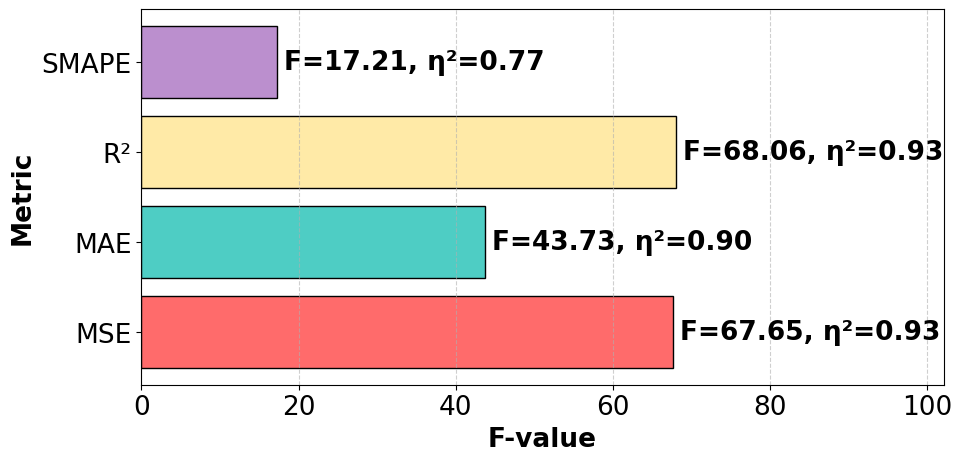

  PDF -> ./overleaf/anova\anova_results.pdf

  Done.


In [8]:
"""
anova_plot.py  —  One-way ANOVA across encoding strategies
  Reads:   ./results/result.db   (metrics table written by Stage 04)
  Writes:  ./overleaf/anova/anova_results.pdf
           ./overleaf/anova/anova_results.png
           ./overleaf/anova/anova_results.log
"""

import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import multipletests

# ── Font size — change this one value to rescale all text in the figure ───────
BASE_FONT_SIZE = 19

# ── Paths ─────────────────────────────────────────────────────────────────────
RESULT_DB = './results/result.db'
OUT_DIR   = './overleaf/anova'
os.makedirs(OUT_DIR, exist_ok=True)

# ── Load metrics table ────────────────────────────────────────────────────────
with sqlite3.connect(RESULT_DB) as conn:
    df = pd.read_sql("SELECT * FROM metrics", conn)

if df.empty:
    raise RuntimeError(f"No rows found in metrics table of {RESULT_DB}. Run Stage 04 first.")

if 'mse' not in df.columns or df['mse'].isna().all():
    df['mse'] = df['rmse'] ** 2

df = df[(df['n_features'] == 100) | (df['encoding'] == 'only_structured')].copy()

# ── Compute F-value and effect size per metric ────────────────────────────────
# Observational unit: fold-averaged metric value per encoding-model combination,
# yielding 6 observations per encoding (one per regression algorithm).
METRICS = [
    ('mse',   'MSE'),
    ('mae',   'MAE'),
    ('r2',    'R²'),
    ('smape', 'SMAPE'),
]

rows = []
for col, label in METRICS:
    # Average over folds to get one value per (model, encoding) cell.
    cell_means = df.groupby(['model', 'encoding'])[col].mean().reset_index()
    cell_means = cell_means.dropna(subset=[col])

    # Keep only balanced subjects (models with all encoding levels).
    enc_counts = cell_means.groupby('model')['encoding'].nunique()
    n_enc = cell_means['encoding'].nunique()
    balanced_models = enc_counts[enc_counts == n_enc].index
    cell_means = cell_means[cell_means['model'].isin(balanced_models)].copy()

    if cell_means['model'].nunique() < 2 or n_enc < 2:
        continue

    aov = AnovaRM(data=cell_means, depvar=col, subject='model', within=['encoding']).fit()
    tbl = aov.anova_table
    f_val  = float(tbl.loc['encoding', 'F Value'])
    p_val  = float(tbl.loc['encoding', 'Pr > F'])
    df_num = float(tbl.loc['encoding', 'Num DF'])
    df_den = float(tbl.loc['encoding', 'Den DF'])
    eta2   = (f_val * df_num) / ((f_val * df_num) + df_den) if (f_val * df_num + df_den) > 0 else np.nan

    rows.append({'Metric': label, 'F_value': f_val, 'p_raw': p_val, 'Effect_Size': eta2})

result_df = pd.DataFrame(rows)
_, p_adj, _, _ = multipletests(result_df['p_raw'].values, alpha=0.05, method='fdr_bh')
result_df['p_adj'] = p_adj

# ── Log file ──────────────────────────────────────────────────────────────────
log_path = os.path.join(OUT_DIR, 'anova_results.log')
with open(log_path, 'w', encoding='utf-8') as log:
    log.write("=" * 60 + "\n")
    log.write("  ANOVA RESULTS — One-way across encoding strategies\n")
    log.write("  Effect size: η² — partial eta squared (from F, df_num, df_den)\n")
    log.write("  Observational unit: per-model fold-mean; model = within-subject factor.\n")
    log.write("=" * 60 + "\n\n")
    log.write(f"  Source DB  : {RESULT_DB}\n")
    log.write(f"  Total rows : {len(df):,}\n")
    log.write(f"  Encodings  : {sorted(df['encoding'].unique())}\n")
    log.write(f"  Models     : {sorted(df['model'].unique())}\n")
    log.write(f"  Folds      : {sorted(df['fold'].unique())}\n\n")
    log.write(f"  {'Metric':<8}  {'F-value':>10}  {'p-raw':>10}  {'p-adj (FDR)':>12}  {'η²':>8}\n")
    log.write(f"  {'-'*58}\n")
    for _, r in result_df.iterrows():
        sig = '**' if r['p_adj'] < 0.01 else ('*' if r['p_adj'] < 0.05 else 'ns')
        log.write(f"  {r['Metric']:<8}  {r['F_value']:>10.2f}  {r['p_raw']:>10.4f}  {r['p_adj']:>12.4f}  {r['Effect_Size']:>8.2f}  {sig}\n")

print(f"  Log -> {log_path}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fancy_colors = ['#FF6B6B', '#4ECDC4', '#FFEAA7', '#BB8FCE']
plt.rcParams.update({
    "font.size":       BASE_FONT_SIZE,
    "axes.titlesize":  BASE_FONT_SIZE,
    "axes.labelsize":  BASE_FONT_SIZE,
    "xtick.labelsize": BASE_FONT_SIZE,
    "ytick.labelsize": BASE_FONT_SIZE,
    "legend.fontsize": BASE_FONT_SIZE,
})

plt.figure(figsize=(10, 5))
bars = plt.barh(result_df["Metric"], result_df["F_value"], color=fancy_colors, edgecolor="black")

for bar, f_val, eff in zip(bars, result_df["F_value"], result_df["Effect_Size"]):
    x_pos = bar.get_width() + 0.9
    y_pos = bar.get_y() + bar.get_height() / 2
    plt.text(x_pos, y_pos, f"F={f_val:.2f}, η²={eff:.2f}", va="center", ha="left", fontsize=BASE_FONT_SIZE, fontweight="bold")

plt.xlabel("F-value", fontweight="bold")
plt.ylabel("Metric", fontweight="bold")
plt.xlim(0, result_df["F_value"].max() * 1.5)
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()

pdf_path = os.path.join(OUT_DIR, 'anova_results.pdf')
plt.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")
plt.show()

print(f"  PDF -> {pdf_path}")
print("\n  Done.")

In [27]:
# =============================================================================
# overleaf_plots.py
#
# Reads result.db produced by Stage 04 and generates four bar-plot PDFs
# (MAE, SMAPE, MSE, R2) that match the colour scheme and layout of the
# per-model PDFs emitted by save_model_artifacts() in pipeline.py.
#
# Output folder : overleaf/
# File names    : overleaf/MAE.pdf  overleaf/SMAPE.pdf
#                 overleaf/MSE.pdf  overleaf/R2.pdf
#
# X-axis  : model  (lasso · linear · mlp · randomforest · ridge · xgboost)
# Bars    : one colour per encoding (same tab10 palette and order as pipeline)
# Values  : mean across all (fold, n_features) combinations in result.db
#           (equivalent to a full-grid average — no cherry-picking of n)
#
# Error bars : ±1 std across the same (fold, n_features) cells
# =============================================================================

import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# ── Paths — keep in sync with pipeline.py CONFIG ─────────────────────────────
RESULT_DB   = './results/result.db'
OVERLEAF_DIR = './overleaf/metrics'

# ── Ordering and palette — identical to pipeline.py enc_order / enc_palette ──
ENC_ORDER   = ['only_structured', 'label', 'tfidf', 'count', 'clinicalbert', 'sentencebert']
MODEL_ORDER = ['lasso', 'linear', 'mlp', 'randomforest', 'ridge', 'xgboost']

# tab10 colours assigned positionally — matches pipeline.py exactly
ENC_PALETTE = {enc: plt.cm.tab10.colors[i] for i, enc in enumerate(ENC_ORDER)}

# ── Metric specs ──────────────────────────────────────────────────────────────
# (db_col_or_derived, filename_stem, y_label, higher_is_better)
METRIC_SPECS = [
    ('mae',   '003. model_comparison_mae',   'MAE (minutes)', False),
    ('smape', '006. model_comparison_smape', 'SMAPE (%)',      False),
    ('mse',   '004. model_comparison_mse',   'MSE',            False),
    ('r2',    '005. model_comparison_r2',    'R²',             True),
]

# ── Plot style ────────────────────────────────────────────────────────────────
# ┌─────────────────────────────────────────────────────────────────────────┐
# │  FONT SIZE — change this single value to scale all text in every plot  │
BASE_FONT_SIZE  = 32
# └─────────────────────────────────────────────────────────────────────────┘

# All font roles are derived from BASE_FONT_SIZE — do not edit these directly
LABEL_FONTSIZE  = BASE_FONT_SIZE * 0.7    # value annotations above bars
TICK_FONTSIZE   = BASE_FONT_SIZE * 0.9    # x-axis model names
AXIS_FONTSIZE   = BASE_FONT_SIZE          # y-axis label
TITLE_FONTSIZE  = BASE_FONT_SIZE * 1.1    # plot title
LEGEND_FONTSIZE = BASE_FONT_SIZE * 0.8    # legend entries and title

BAR_WIDTH      = 0.12
BAR_ALPHA      = 0.85
EDGECOLOR      = 'black'
EDGELINEWIDTH  = 0.4
FIG_WIDTH      = 18
FIG_HEIGHT     = 6
LEGEND_FIG_WIDTH  =20    # width  of the standalone legend.pdf — change freely
LEGEND_FIG_HEIGHT = 1.2   # height of the standalone legend.pdf — change freely

os.makedirs(OVERLEAF_DIR, exist_ok=True)


def load_metrics() -> pd.DataFrame:
    """Load the metrics table and derive MSE from RMSE."""
    with sqlite3.connect(RESULT_DB) as conn:
        df = pd.read_sql("SELECT * FROM metrics", conn)
    # MSE = RMSE²  (RMSE is stored; MSE is not)
    if 'rmse' in df.columns:
        df['mse'] = df['rmse'] ** 2
    return df


def aggregate(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    """
    Return a DataFrame with columns [model, encoding, mean, std].
    Mean and std are computed across ALL (fold, n_features) rows,
    so every combination contributes equally.
    """
    grp = (
        df.groupby(['model', 'encoding'])[metric]
        .agg(['mean', 'std'])
        .reset_index()
        .rename(columns={'mean': 'mean', 'std': 'std'})
    )
    grp['std'] = grp['std'].fillna(0.0)
    return grp


def make_plot(agg: pd.DataFrame, metric_label: str, y_label: str, higher_better: bool) -> plt.Figure:
    """
    Build a grouped bar chart.
      X groups  = models
      Bar colour = encoding (tab10, same order as pipeline)
    """
    # Keep only orderings actually present in data
    models   = [m for m in MODEL_ORDER  if m in agg['model'].unique()]
    encodings = [e for e in ENC_ORDER    if e in agg['encoding'].unique()]
    n_models   = len(models)
    n_encs     = len(encodings)

    offsets = (np.arange(n_encs) - (n_encs - 1) / 2.0) * BAR_WIDTH

    fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

    best_val, best_bar = None, None

    for si, enc in enumerate(encodings):
        sub = agg[agg['encoding'] == enc].set_index('model')
        means = np.array([sub.loc[m, 'mean'] if m in sub.index else np.nan for m in models])
        stds  = np.array([sub.loc[m, 'std']  if m in sub.index else np.nan for m in models])
        x_pos = np.arange(n_models) + offsets[si]
        valid = ~np.isnan(means)
        if not valid.any():
            continue

        bars = ax.bar(
            x_pos[valid], means[valid],
            width=BAR_WIDTH * 0.92,
            color=ENC_PALETTE[enc],
            alpha=BAR_ALPHA,
            edgecolor=EDGECOLOR,
            linewidth=EDGELINEWIDTH,
            label=enc,
        )

        # Track global best for red border
        for bar, val in zip(bars, means[valid]):
            if (best_val is None
                    or (higher_better and val > best_val)
                    or (not higher_better and val < best_val)):
                best_val, best_bar = val, bar

    if best_bar is not None:
        best_bar.set_edgecolor('red')
        best_bar.set_linewidth(2.0)

    ax.set_xticks(np.arange(n_models))
    ax.set_xticklabels(models, fontsize=TICK_FONTSIZE)
    ax.set_ylabel(y_label, fontsize=AXIS_FONTSIZE)

    ax.grid(axis='y', linestyle='--', alpha=0.4)

    fig.tight_layout()
    return fig


def save_legend(encodings: list):
    """Save a standalone horizontal legend as overleaf/metrics/legend.pdf."""
    handles = [
        plt.Rectangle((0, 0), 1, 1, color=ENC_PALETTE[enc], alpha=BAR_ALPHA,
                       edgecolor=EDGECOLOR, linewidth=EDGELINEWIDTH, label=enc)
        for enc in encodings
    ]
    fig, ax = plt.subplots(figsize=(LEGEND_FIG_WIDTH, LEGEND_FIG_HEIGHT))
    ax.axis('off')
    ax.legend(
        handles=handles,
        title='Encoding Techniques',
        title_fontsize=LEGEND_FONTSIZE,
        fontsize=LEGEND_FONTSIZE,
        loc='center',
        ncol=len(encodings),
        frameon=True,
        mode='expand',
        columnspacing=2.0,
        handlelength=1.5,
        handletextpad=0.6,
    )
    fig.tight_layout()
    out_path = os.path.join(OVERLEAF_DIR, '002. legend_only.pdf')
    with PdfPages(out_path) as pdf:
        pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)
    print(f"  ✅ {out_path}")


def save_log(df: pd.DataFrame):
    """
    Write a single human-readable .log file covering all four metrics.
    Structure:
      - One section per metric, sorted by (model, encoding)
      - A cross-metric summary table at the end (best model+encoding per metric)
    """
    log_path = os.path.join(OVERLEAF_DIR, 'metrics_summary.log')
    W = 100   # line width

    def hline(char='-'): return char * W

    lines = []
    lines.append('=' * W)
    lines.append('  METRICS SUMMARY — overleaf/metrics/metrics_summary.log')
    lines.append(f'  Source : {RESULT_DB}')
    lines.append(f'  Rows   : {len(df):,}  |  Folds : {sorted(df["fold"].unique())}')
    lines.append(f'  Models : {sorted(df["model"].unique())}')
    lines.append(f'  Encodings : {sorted(df["encoding"].unique())}')
    lines.append('  NOTE   : mean and std computed across ALL (fold, n_features) combinations')
    lines.append('=' * W)

    agg_all = {}   # {db_col: agg_df}  — reused for summary section

    for db_col, stem, y_label, higher_better in METRIC_SPECS:
        if db_col not in df.columns:
            lines.append(f'\n  ⚠  Column "{db_col}" not found — section skipped.\n')
            continue

        agg = aggregate(df, db_col)
        agg_all[db_col] = (agg, stem, higher_better)

        lines.append('')
        lines.append(hline('='))
        lines.append(f'  METRIC : {stem}  ({y_label})')
        lines.append(f'  {"Higher is better" if higher_better else "Lower is better"}')
        lines.append(hline('='))

        # Per-model sections
        for model in MODEL_ORDER:
            sub = agg[agg['model'] == model].copy()
            if sub.empty:
                continue
            sub = sub.set_index('encoding').reindex([e for e in ENC_ORDER if e in sub.index])
            lines.append('')
            lines.append(f'  Model : {model.upper()}')
            lines.append(f'  {hline("-")}')
            lines.append(f'  {"Encoding":<20} {"Mean":>12} {"Std":>12}')
            lines.append(f'  {hline("-")}')
            for enc, row in sub.iterrows():
                lines.append(f'  {enc:<20} {row["mean"]:>12.4f} {row["std"]:>12.4f}')

        # Aggregate across all models — encoding-level summary
        lines.append('')
        lines.append(f'  {hline("-")}')
        lines.append(f'  ENCODING-LEVEL SUMMARY  (mean across all models)')
        lines.append(f'  {hline("-")}')
        enc_grp = agg.groupby('encoding')['mean'].agg(['mean', 'std']).reindex(ENC_ORDER).dropna()
        lines.append(f'  {"Encoding":<20} {"Mean":>12} {"Std":>12}')
        lines.append(f'  {hline("-")}')
        for enc, row in enc_grp.iterrows():
            lines.append(f'  {enc:<20} {row["mean"]:>12.4f} {row["std"]:>12.4f}')

        # Model-level summary
        lines.append('')
        lines.append(f'  {hline("-")}')
        lines.append(f'  MODEL-LEVEL SUMMARY  (mean across all encodings)')
        lines.append(f'  {hline("-")}')
        mdl_grp = agg.groupby('model')['mean'].agg(['mean', 'std']).reindex(MODEL_ORDER).dropna()
        lines.append(f'  {"Model":<20} {"Mean":>12} {"Std":>12}')
        lines.append(f'  {hline("-")}')
        for mdl, row in mdl_grp.iterrows():
            lines.append(f'  {mdl:<20} {row["mean"]:>12.4f} {row["std"]:>12.4f}')

    # ── Cross-metric best-configuration summary ───────────────────────────────
    lines.append('')
    lines.append(hline('='))
    lines.append('  BEST CONFIGURATION PER METRIC')
    lines.append(hline('='))
    lines.append(f'  {"Metric":<8} {"Model":<16} {"Encoding":<22} {"Mean":>12} {"Std":>12}')
    lines.append(f'  {hline("-")}')
    for db_col, (agg, stem, higher_better) in agg_all.items():
        idx  = agg['mean'].idxmax() if higher_better else agg['mean'].idxmin()
        best = agg.loc[idx]
        lines.append(f'  {stem:<8} {best["model"]:<16} {best["encoding"]:<22} {best["mean"]:>12.4f} {best["std"]:>12.4f}')

    lines.append('')
    lines.append(hline('='))

    with open(log_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines) + '\n')
    print(f"  ✅ {log_path}")


def main():
    print(f"Loading {RESULT_DB} ...")
    df = load_metrics()
    print(f"  {len(df):,} metric rows  |  "
          f"models: {sorted(df['model'].unique())}  |  "
          f"encodings: {sorted(df['encoding'].unique())}")

    for db_col, stem, y_label, higher_better in METRIC_SPECS:
        if db_col not in df.columns:
            print(f"  ⚠  Column '{db_col}' not found — skipping {stem}.pdf")
            continue

        agg = aggregate(df, db_col)
        fig = make_plot(agg, metric_label=stem, y_label=y_label, higher_better=higher_better)

        out_path = os.path.join(OVERLEAF_DIR, f'{stem}.pdf')
        with PdfPages(out_path) as pdf:
            pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)
        print(f"  ✅ {out_path}")

    # Standalone legend — derived from encodings actually present in data
    encodings_present = [e for e in ENC_ORDER if e in df['encoding'].unique()]
    save_legend(encodings_present)

    # Single log file covering all metrics
    save_log(df)

    print("\nDone.  All plots saved to:", OVERLEAF_DIR)


if __name__ == '__main__':
    main()

Loading ./results/result.db ...
  630 metric rows  |  models: ['lasso', 'linear', 'mlp', 'randomforest', 'ridge', 'xgboost']  |  encodings: ['clinicalbert', 'count', 'label', 'only_structured', 'sentencebert', 'tfidf']
  ✅ ./overleaf/metrics\003. model_comparison_mae.pdf
  ✅ ./overleaf/metrics\006. model_comparison_smape.pdf
  ✅ ./overleaf/metrics\004. model_comparison_mse.pdf
  ✅ ./overleaf/metrics\005. model_comparison_r2.pdf
  ✅ ./overleaf/metrics\002. legend_only.pdf
  ✅ ./overleaf/metrics\metrics_summary.log

Done.  All plots saved to: ./overleaf/metrics


C:\Users\mnoorche\AppData\Local\Temp\ipykernel_42216\2986248375.py:161: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.Rectangle((0, 0), 1, 1, color=ENC_PALETTE[enc], alpha=BAR_ALPHA,
